In [99]:
import numpy as np
import os
import json
import cv2
import math
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
from glob import glob

import torch
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F

from thop import profile
from torchsummary import summary

%matplotlib inline
matplotlib.rcParams['figure.facecolor'] = '#ffffff'


In [100]:
result = torch.cuda.get_device_name(torch.cuda.current_device()) if torch.cuda.is_available() else "cpu"
print("Current device: " + result)
torch.cuda.empty_cache()


Current device: NVIDIA GeForce MX250


# Dataloader

In [101]:
config = {
  "data_dir": './FreiHAND_pub_v2',
  "data_num": 70000, #70000
  "train_num": 55000, #55000
  "val_num": 5000, #5000
  "test_num": 10000, #10000
  "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
  # you can set your own training configurations
  "batch_size": 32,
  "learning_rate": 0.001,
  "n_epochs": 50,
}

In [102]:
transform = transforms.Compose([transforms.ToTensor()])

# training / validation datasets
train_ds = datasets.MNIST('./data', train=True, transform=transform, download=True)
test_ds = datasets.MNIST('./data', train=False, transform=transform, download=True)

# split train_ds into train_ds and val_ds
train_ds, val_ds = random_split(train_ds, [config["train_num"], config["val_num"]])

# get the first 100 samples from train_ds
# train_ds = torch.utils.data.Subset(train_ds, range(128))
# val_ds = torch.utils.data.Subset(val_ds, range(64))
# test_ds = torch.utils.data.Subset(test_ds, range(64))

# data loaders
train_dl = DataLoader(train_ds, config["batch_size"], shuffle=True, drop_last=True, num_workers=4)
val_dl = DataLoader(val_ds, config["batch_size"], shuffle=True, drop_last=True, num_workers=4)
test_dl = DataLoader(test_ds, config["batch_size"], shuffle=True, drop_last=True, num_workers=4)


print("Total dataset length: ", config['data_num'])
print("Train dataset length: ", len(train_ds))
print("Valid dataset length: ", len(val_ds))
print("Test dataset length: ", len(test_ds))

Total dataset length:  70000
Train dataset length:  55000
Valid dataset length:  5000
Test dataset length:  10000


# Model

+ Model Specifications:
  + Input: **`[B, 3, 224, 224]`**
  + Output: **`[B, 21, 2]`** --> 21 for the num of the landmarks, 2 for the coordinates in (x, y) format

In [103]:
class Net(nn.Module):
    def __init__(self, num_classes=10):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, stride=1, padding=2)
        self.conv5 = nn.Conv2d(64, 64, kernel_size=5, stride=1, padding=2)
        self.conv6 = nn.Conv2d(64, 64, kernel_size=5, stride=1, padding=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        conv1_out = x
        x = self.maxpool(x)
        x = F.relu(self.conv2(x))
        conv2_out = x
        x = F.relu(self.conv3(x))
        conv3_out = x
        x = F.relu(self.conv4(x) + x)
        conv4_out = x
        x = F.relu(self.conv5(x))
        conv5_out = x
        x = F.relu(self.conv6(x) + x)
        conv6_out = x
        x = self.maxpool(x)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x, [conv1_out, conv2_out, conv3_out, conv4_out, conv5_out, conv6_out]

model = Net().to(config["device"])

In [ ]:
# initialize tracker for minimum validation loss
valid_loss_min = np.inf # set initial "min" to infinity

# initialize history for recording what we want to know
history = []

for epoch in range(config["n_epochs"]):
    # monitor training loss, validation loss and learning rate
    train_loss = 0.0
    valid_loss = 0.0
    lrs    = []
    train_acc = 0
    val_acc = 0
    result = {'train_loss': [], 'val_loss': [], 'test_loss': [], 'lrs': [], 'train_acc': [], 'val_acc': [], 'test_acc': []}

    # prepare model for training
    model.train()

    #######################
    # train the model #
    #######################
    for batch in tqdm(train_dl):
        images, labels = batch
        images, labels = images.to(config['device']), labels.to(config['device'])
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output, _ = model(images)
        # calculate the loss
        loss = F.cross_entropy(output, labels)
        pred = output.argmax(dim=1, keepdim=True)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        scheduler.step()

        # record learning rate
        lrs.append(optimizer.param_groups[0]['lr'])

        # update running training loss
        train_loss += loss.item()*images.size(0) # images.size(0) is the batch size
        train_acc += pred.eq(labels.view_as(pred)).sum().item()

    train_acc = (100. * train_acc) / len(train_dl.dataset)
    ######################
    # validate the model #
    ######################
    model.eval()
    for batch in val_dl:
        images, labels = batch
        images, labels = images.to(config['device']), labels.to(config['device'])
        # compute predicted outputs by passing inputs to the model
        output, _ = model(images)
        # calculate the loss
        loss = F.cross_entropy(output, labels)
        pred = output.argmax(dim=1, keepdim=True)
        # update running validation loss
        valid_loss += loss.item()*images.size(0) # images.size(0) is the batch size
        val_acc += pred.eq(labels.view_as(pred)).sum().item()
        

    val_acc = (100. * val_acc) / len(val_dl.dataset)
    
    ##################
    # test the model #
    ##################
    test_loss = 0
    test_acc = 0

    with torch.no_grad():
        model.eval()
        for batch in test_dl:
            images, labels = batch
            images, labels = images.to(config['device']), labels.to(config['device'])
            # compute predicted outputs by passing inputs to the model
            output, _ = model(images)
            # calculate the loss
            loss = F.cross_entropy(output, labels)
            pred = output.argmax(dim=1, keepdim=True)
            # update running validation loss
            test_loss += loss.item()*images.size(0) # images.size(0) is the batch size
            test_acc += pred.eq(labels.view_as(pred)).sum().item()
            
    test_loss /= len(test_dl.dataset)
    test_acc = (100. * test_acc) / len(test_dl.dataset)
    
    # print training/validation statistics
    # calculate average loss over an epoch
    train_loss = train_loss/len(train_dl.dataset)
    result['train_loss'] = train_loss
    valid_loss = valid_loss/len(val_dl.dataset)
    result['val_loss'] = valid_loss
    result['test_loss'] = test_loss
    result['lrs'] = lrs
    result['train_acc'] = train_acc
    result['val_acc'] = val_acc
    result['test_acc'] = test_acc
    history.append(result)

    print('Epoch {:2d}: Learning Rate: {:.6f} train_acc: {:.2f}% val_acc: {:.2f}% test_acc: {:.2f}% Train Loss: {:.6f} Valid Loss:{:.6f} Test Loss:{:.6}'.format(
        epoch+1,
        lrs[-1],
        train_acc,
        val_acc,
        test_acc,
        train_loss,
        valid_loss,
        test_loss
        ))

    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print("Validation loss decreased({:.6f}-->{:.6f}). Saving model ..".format(
        valid_loss_min,
        valid_loss
        ))
        torch.save(model.state_dict(),"model.pt")
        valid_loss_min = valid_loss

  0%|          | 0/1718 [00:00<?, ?it/s]

100%|██████████| 1718/1718 [01:55<00:00, 14.89it/s]


Epoch  1: Learning Rate: 0.000999 train_acc: 94.74% val_acc: 97.58% test_acc: 97.58% Train Loss: 0.163875 Valid Loss:0.083367 Test Loss:0.0748125
Validation loss decreased(inf-->0.083367). Saving model ..


100%|██████████| 1718/1718 [01:29<00:00, 19.15it/s]


Epoch  2: Learning Rate: 0.000996 train_acc: 98.26% val_acc: 98.84% test_acc: 98.74% Train Loss: 0.057577 Valid Loss:0.042505 Test Loss:0.0348626
Validation loss decreased(0.083367-->0.042505). Saving model ..


...

100%|██████████| 1718/1718 [01:27<00:00, 19.71it/s]


Epoch 24: Learning Rate: 0.000555 train_acc: 99.83% val_acc: 99.06% test_acc: 98.92% Train Loss: 0.005209 Valid Loss:0.056177 Test Loss:0.0697846


100%|██████████| 1718/1718 [01:14<00:00, 23.10it/s]


Epoch 25: Learning Rate: 0.000525 train_acc: 99.87% val_acc: 99.12% test_acc: 98.93% Train Loss: 0.003223 Valid Loss:0.076155 Test Loss:0.076789


100%|██████████| 1718/1718 [01:21<00:00, 21.08it/s]


# Optimizer and Scheduler (optional)

In [104]:
optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])

# L2 regularization
# optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'], weight_decay=1e-4)

In [105]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = (len(train_dl.dataset) / config["batch_size"]) * config["n_epochs"], eta_min = 0.00005)
print((len(train_dl.dataset) / config["batch_size"]) * config["n_epochs"])

85937.5


# Training
  + Record the **`loss / epoch`** learning curve
  + If using learning rate scheduler, record the **`lr / epoch`** curve

In [106]:
# weight_path = 'model_weights.pth'

# checkpoint = torch.load(weight_path)
# model.load_state_dict(checkpoint, strict=True)

In [ ]:
# initialize tracker for minimum validation loss
valid_loss_min = np.inf # set initial "min" to infinity

# initialize history for recording what we want to know
history = []

for epoch in range(config["n_epochs"]):
    # monitor training loss, validation loss and learning rate
    train_loss = 0.0
    valid_loss = 0.0
    lrs    = []
    train_acc = 0
    val_acc = 0
    result = {'train_loss': [], 'val_loss': [], 'test_loss': [], 'lrs': [], 'train_acc': [], 'val_acc': [], 'test_acc': []}

    # prepare model for training
    model.train()

    #######################
    # train the model #
    #######################
    for batch in tqdm(train_dl):
        images, labels = batch
        images, labels = images.to(config['device']), labels.to(config['device'])
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output, _ = model(images)
        # calculate the loss
        loss = F.cross_entropy(output, labels)
        pred = output.argmax(dim=1, keepdim=True)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        scheduler.step()

        # record learning rate
        lrs.append(optimizer.param_groups[0]['lr'])

        # update running training loss
        train_loss += loss.item()*images.size(0) # images.size(0) is the batch size
        train_acc += pred.eq(labels.view_as(pred)).sum().item()

    train_acc = (100. * train_acc) / len(train_dl.dataset)
    ######################
    # validate the model #
    ######################
    model.eval()
    for batch in val_dl:
        images, labels = batch
        images, labels = images.to(config['device']), labels.to(config['device'])
        # compute predicted outputs by passing inputs to the model
        output, _ = model(images)
        # calculate the loss
        loss = F.cross_entropy(output, labels)
        pred = output.argmax(dim=1, keepdim=True)
        # update running validation loss
        valid_loss += loss.item()*images.size(0) # images.size(0) is the batch size
        val_acc += pred.eq(labels.view_as(pred)).sum().item()
        

    val_acc = (100. * val_acc) / len(val_dl.dataset)
    
    ##################
    # test the model #
    ##################
    test_loss = 0
    test_acc = 0

    with torch.no_grad():
        model.eval()
        for batch in test_dl:
            images, labels = batch
            images, labels = images.to(config['device']), labels.to(config['device'])
            # compute predicted outputs by passing inputs to the model
            output, _ = model(images)
            # calculate the loss
            loss = F.cross_entropy(output, labels)
            pred = output.argmax(dim=1, keepdim=True)
            # update running validation loss
            test_loss += loss.item()*images.size(0) # images.size(0) is the batch size
            test_acc += pred.eq(labels.view_as(pred)).sum().item()
            
    test_loss /= len(test_dl.dataset)
    test_acc = (100. * test_acc) / len(test_dl.dataset)
    
    # print training/validation statistics
    # calculate average loss over an epoch
    train_loss = train_loss/len(train_dl.dataset)
    result['train_loss'] = train_loss
    valid_loss = valid_loss/len(val_dl.dataset)
    result['val_loss'] = valid_loss
    result['test_loss'] = test_loss
    result['lrs'] = lrs
    result['train_acc'] = train_acc
    result['val_acc'] = val_acc
    result['test_acc'] = test_acc
    history.append(result)

    print('Epoch {:2d}: Learning Rate: {:.6f} train_acc: {:.2f}% val_acc: {:.2f}% test_acc: {:.2f}% Train Loss: {:.6f} Valid Loss:{:.6f} Test Loss:{:.6}'.format(
        epoch+1,
        lrs[-1],
        train_acc,
        val_acc,
        test_acc,
        train_loss,
        valid_loss,
        test_loss
        ))

    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print("Validation loss decreased({:.6f}-->{:.6f}). Saving model ..".format(
        valid_loss_min,
        valid_loss
        ))
        torch.save(model.state_dict(),"model.pt")
        valid_loss_min = valid_loss

  0%|          | 0/1718 [00:00<?, ?it/s]

100%|██████████| 1718/1718 [01:55<00:00, 14.89it/s]


Epoch  1: Learning Rate: 0.000999 train_acc: 94.74% val_acc: 97.58% test_acc: 97.58% Train Loss: 0.163875 Valid Loss:0.083367 Test Loss:0.0748125
Validation loss decreased(inf-->0.083367). Saving model ..


100%|██████████| 1718/1718 [01:29<00:00, 19.15it/s]


Epoch  2: Learning Rate: 0.000996 train_acc: 98.26% val_acc: 98.84% test_acc: 98.74% Train Loss: 0.057577 Valid Loss:0.042505 Test Loss:0.0348626
Validation loss decreased(0.083367-->0.042505). Saving model ..


...

Epoch 24: Learning Rate: 0.000555 train_acc: 99.83% val_acc: 99.06% test_acc: 98.92% Train Loss: 0.005209 Valid Loss:0.056177 Test Loss:0.0697846


100%|██████████| 1718/1718 [01:14<00:00, 23.10it/s]


Epoch 25: Learning Rate: 0.000525 train_acc: 99.87% val_acc: 99.12% test_acc: 98.93% Train Loss: 0.003223 Valid Loss:0.076155 Test Loss:0.076789


100%|██████████| 1718/1718 [01:21<00:00, 21.08it/s]


: 

In [ ]:
torch.save(model.state_dict(), 'C:/Users/Ken/Desktop/113-1/DL/HW2/model_weights.pth')
print("Save model weight successfully.")

Save model weight successfully.


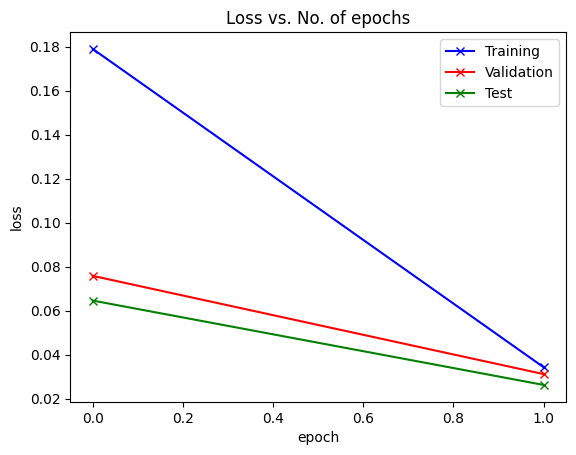

In [ ]:
def plot_losses(history):
  train_losses = [x.get('train_loss') for x in history]
  val_losses = [x['val_loss'] for x in history]
  test_losses = [x['test_loss'] for x in history]
  plt.plot(train_losses, '-bx')
  plt.plot(val_losses, '-rx')
  plt.plot(test_losses, '-gx')
  plt.xlabel('epoch')
  plt.ylabel('loss')
  plt.legend(['Training', 'Validation', 'Test'])
  plt.title('Loss vs. No. of epochs');

plot_losses(history)

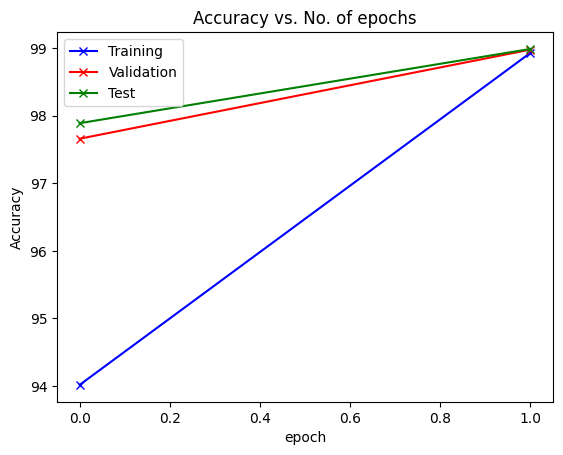

In [ ]:
  
def plot_acc(history):
  train_acc = [x.get('train_acc') for x in history]
  val_acc = [x['val_acc'] for x in history]
  test_acc = [x['test_acc'] for x in history]
  plt.plot(train_acc, '-bx')
  plt.plot(val_acc, '-rx')
  plt.plot(test_acc, '-gx')
  plt.xlabel('epoch')
  plt.ylabel('Accuracy')
  plt.legend(['Training', 'Validation', 'Test'])
  plt.title('Accuracy vs. No. of epochs');
  
plot_acc(history)

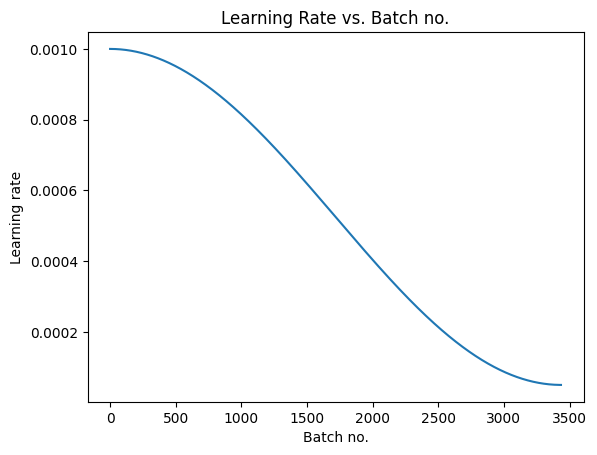

In [ ]:
def plot_lrs(history):
  lrs = np.concatenate([x.get('lrs', []) for x in history])
  plt.plot(lrs)
  plt.xlabel('Batch no.')
  plt.ylabel('Learning rate')
  plt.title('Learning Rate vs. Batch no.');

plot_lrs(history)

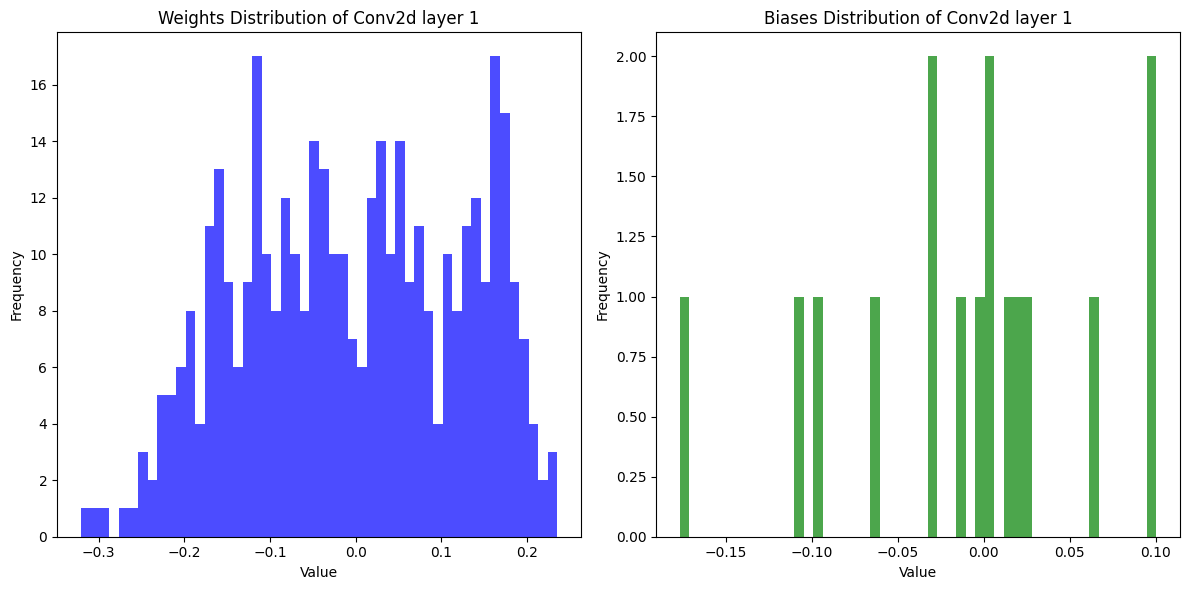

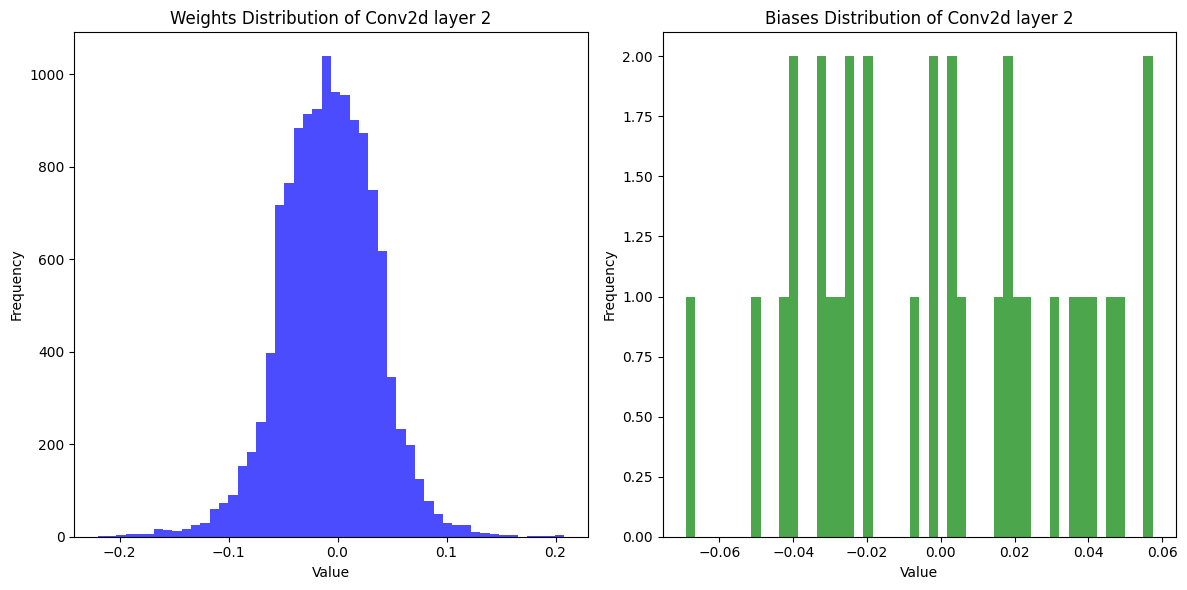

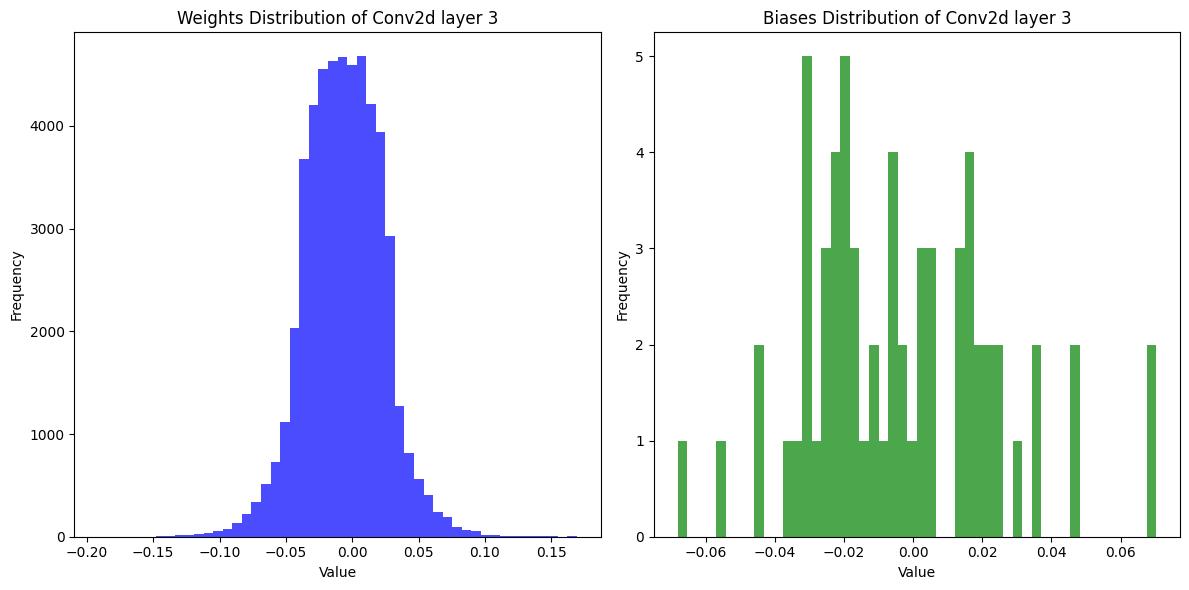

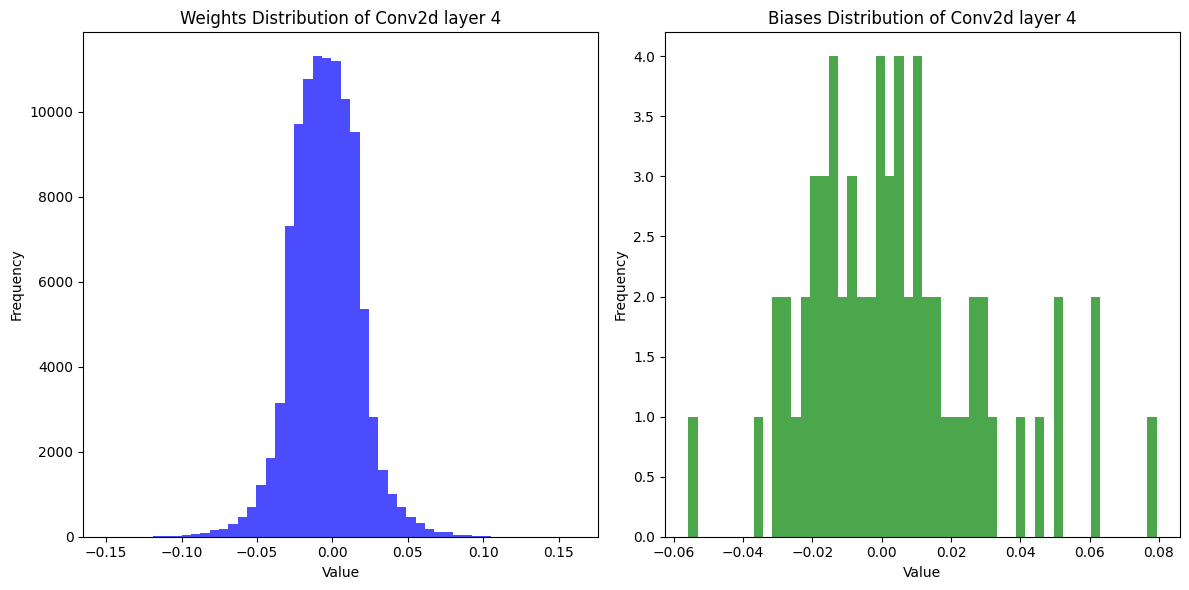

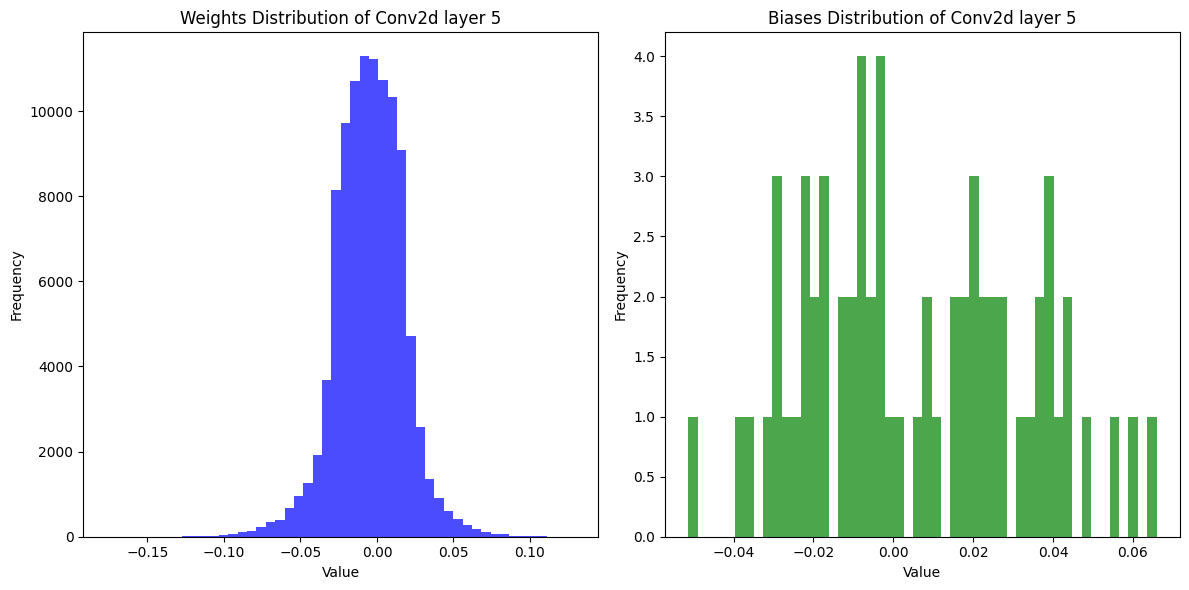

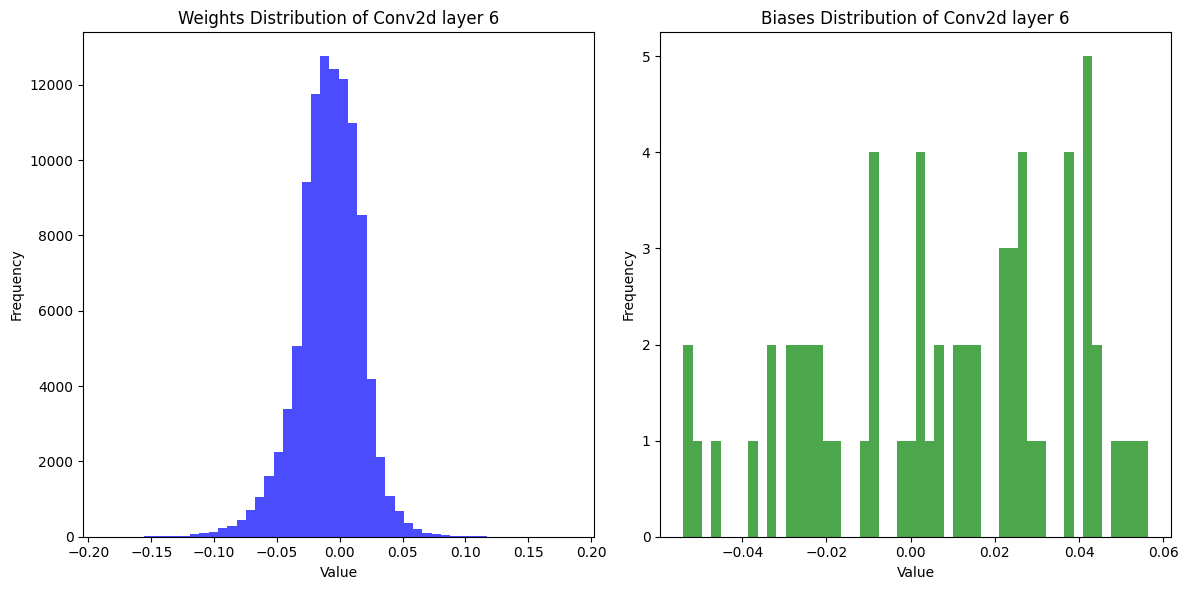

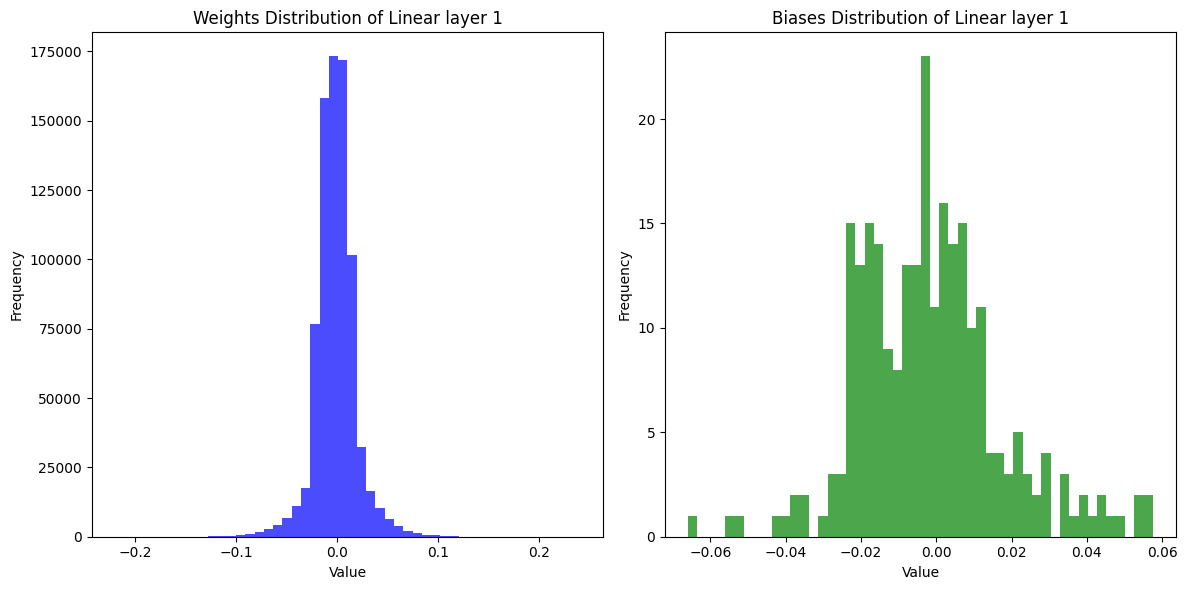

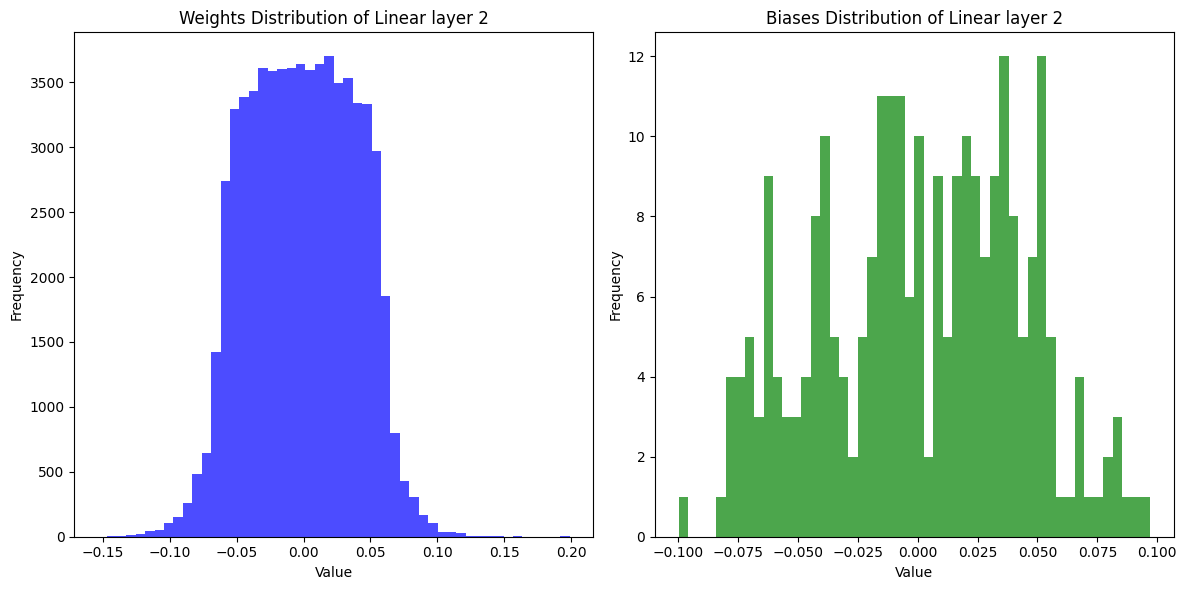

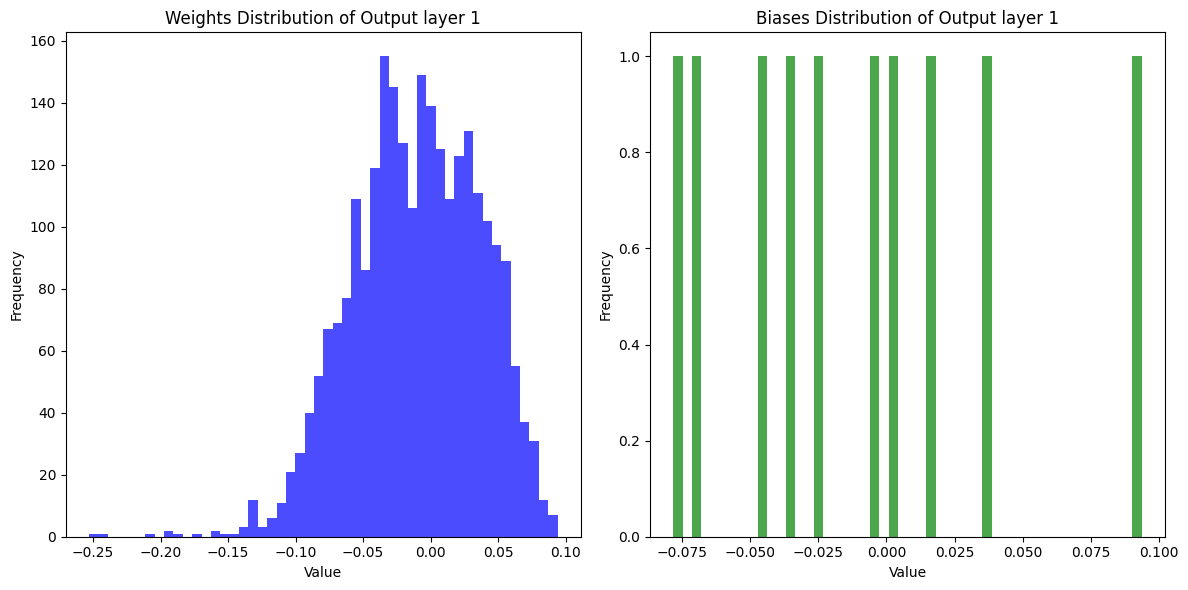

In [ ]:
def plot_weights_and_biases(model):
    model_layers = [layer for layer in model.modules() if isinstance(layer, (nn.Conv2d, nn.Linear))]
    
    i_linear = 0
    for i, layer in enumerate(model_layers):
        weights = layer.weight.data.cpu().numpy().flatten()
        biases = layer.bias.data.cpu().numpy().flatten()
        if isinstance(layer, nn.Conv2d):
            layer_type = 'Conv2d'
            layer_num = i+1
        elif i == len(model_layers)-1:
            layer_type = 'Output'
            layer_num = 1
        else:
            layer_type = 'Linear'
            layer_num = i_linear+1
            i_linear += 1
        
        # 繪製權重分佈
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.hist(weights, bins=50, color='blue', alpha=0.7)
        plt.title('Weights Distribution of {} layer {}'.format(layer_type, layer_num))
        plt.xlabel('Value')
        plt.ylabel('Frequency')

        # 繪製偏置分佈
        plt.subplot(1, 2, 2)
        plt.hist(biases, bins=50, color='green', alpha=0.7)
        plt.title('Biases Distribution of {} layer {}'.format(layer_type, layer_num))
        plt.xlabel('Value')
        plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

# 假設 model 已經定義並訓練
plot_weights_and_biases(model)

# Load your model

In [ ]:
weight_path = 'C:/Users/Ken/Desktop/113-1/DL/HW2/model_weights.pth'

checkpoint = torch.load(weight_path)
model.eval()
model.load_state_dict(checkpoint, strict=True)
model.to(config["device"])

C:\Users\Ken\AppData\Local\Temp\ipykernel_23960\3157351769.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path)


Net(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv4): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv5): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv6): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=3136, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)

In [ ]:
# print(model)

# Testing part

In [ ]:
def plot_feature_maps(feature_maps_1, feature_maps_2, layer_names, type1, type2):

    for i, (feature_map_1, feature_map_2) in enumerate(zip(feature_maps_1, feature_maps_2)):
        # print("feature_map shape: ", feature_map_1.shape)
        num_features = feature_map_1.shape[1]
        num_cols = 8  # show 8 feature maps per row
        num_rows = num_features // num_cols
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
        fig.suptitle(f'{type1} prediction Feature Maps of {layer_names[i]}')
        
        for j in range(num_features):
            row = j // num_cols
            col = j % num_cols
            ax = axes[row, col] if num_rows > 1 else axes[col]
            ax.imshow(feature_map_1[0, j].cpu().detach().numpy(), cmap='gray')
            ax.axis('off')
            
        for j in range(num_features, num_rows * num_cols):
            row = j // num_cols
            col = j % num_cols
            ax = axes[row, col] if num_rows > 1 else axes[col]
            ax.axis('off')
            
        plt.show()
        
        # print("feature_map shape: ", feature_map_1.shape)
        num_features = feature_map_2.shape[1]
        num_cols = 8  # show 8 feature maps per row
        num_rows = num_features // num_cols
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
        fig.suptitle(f'{type2} prediction Feature Maps of {layer_names[i]}')
        
        for j in range(num_features):
            row = j // num_cols
            col = j % num_cols
            ax = axes[row, col] if num_rows > 1 else axes[col]
            ax.imshow(feature_map_2[0, j].cpu().detach().numpy(), cmap='gray')
            ax.axis('off')
            
        for j in range(num_features, num_rows * num_cols):
            row = j // num_cols
            col = j % num_cols
            ax = axes[row, col] if num_rows > 1 else axes[col]
            ax.axis('off')
            
        plt.show()


In [ ]:
def test(model, test_dl):
    print("Test dataset length: ", len(test_dl.dataset))
    test_loss = 0
    test_acc = 0
    get_wrong_example = True
    show_example = True
    
    with torch.no_grad():
        model.eval()
        for batch in tqdm(test_dl):
            images, labels = batch
            images, labels = images.to(config['device']), labels.to(config['device'])
            # compute predicted outputs by passing inputs to the model
            output, feature_maps = model(images)
            # calculate the loss
            loss = F.cross_entropy(output, labels)
            pred = output.argmax(dim=1, keepdim=True)
            # update running validation loss
            test_loss += loss.item() * images.size(0)  # images.size(0) is the batch size
            test_acc += pred.eq(labels.view_as(pred)).sum().item()
            
            # record correct predictions
            correct_mask = pred.eq(labels.view_as(pred))  # mask of correct predictions
            correct_mask = correct_mask.view(-1) # flatten the mask
            correct_images = images[correct_mask]
            correct_labels = labels[correct_mask]
            correct_preds = pred[correct_mask]
            # print(correct_labels)
            
            if get_wrong_example:
                # record incorrect predictions
                incorrect_mask = ~pred.eq(labels.view_as(pred))  # mask of incorrect predictions
                incorrect_mask = incorrect_mask.view(-1) # flatten the mask
                incorrect_images = images[incorrect_mask]
                incorrect_labels = labels[incorrect_mask]
                incorrect_preds = pred[incorrect_mask]
                if incorrect_mask.any():
                    get_wrong_example = False
                # print(incorrect_labels)
            
            for i in range(len(correct_images)):
                if len(correct_images) == 0 or len(incorrect_images) == 0:
                    break
                if correct_preds[i].item() == incorrect_preds[0].item() and show_example:
                    # Plot incorrect and correct examples with the same prediction
                    
                    # Plot incorrect example
                    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                    
                    incorrect_images_np = incorrect_images[0].cpu().squeeze().numpy()
                    axes[0].imshow(incorrect_images_np, cmap='gray')
                    axes[0].set_title(f'Incorrect Prediction\nTrue: {incorrect_labels[0].item()}\nPred: {incorrect_preds[0].item()}')
                    axes[0].axis('off')
                    
                    # Plot correct example
                    correct_images_np = correct_images[i].cpu().squeeze().numpy()
                    axes[1].imshow(correct_images_np, cmap='gray')
                    axes[1].set_title(f'Correct Prediction\nTrue: {correct_labels[i].item()}\nPred: {correct_preds[i].item()}')
                    axes[1].axis('off')
                    
                    plt.show()
                        
                    # Plot feature maps for both incorrect and correct examples
                    model.eval()
                    with torch.no_grad():
                        _, incorrect_feature_maps = model(incorrect_images[0].unsqueeze(0).to(config['device']))
                        _, correct_feature_maps = model(correct_images[i].unsqueeze(0).to(config['device']))
                        
                    layer_names = ['conv1', 'conv2', 'conv3', 'conv4', 'conv5', 'conv6']
                    plot_feature_maps(incorrect_feature_maps, correct_feature_maps, layer_names, "Incorrect", "Correct")
                    # plot_feature_maps(correct_feature_maps, layer_names, "Correct")
                    
                    show_example = False
                    break
            
    test_loss /= len(test_dl.dataset)
    test_acc = (100. * test_acc) / len(test_dl.dataset)
    print('\nTest Set: Average loss: {:.4f}, Accuracy: {:.2f}%'.format(test_loss, test_acc))

    return test_loss, test_acc

Test dataset length:  10000


  0%|          | 1/312 [00:13<1:10:16, 13.56s/it]

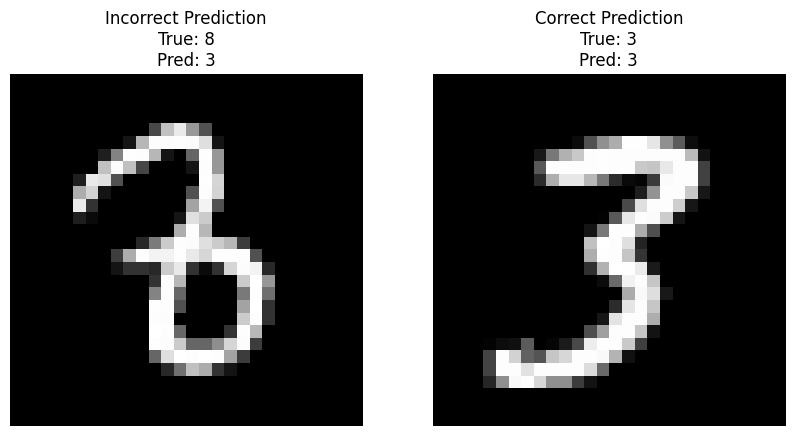

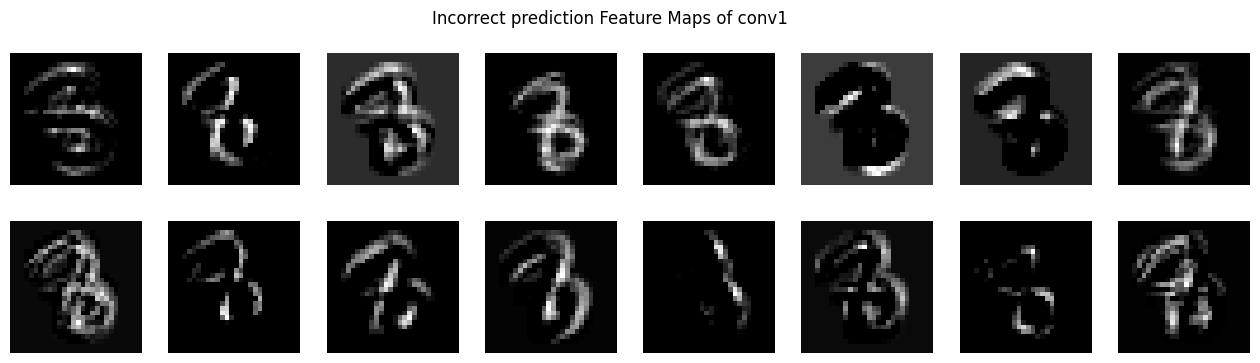

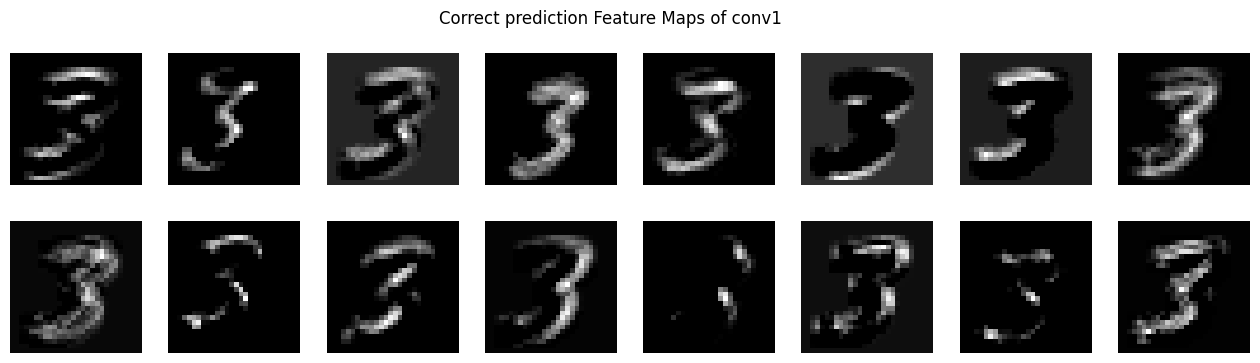

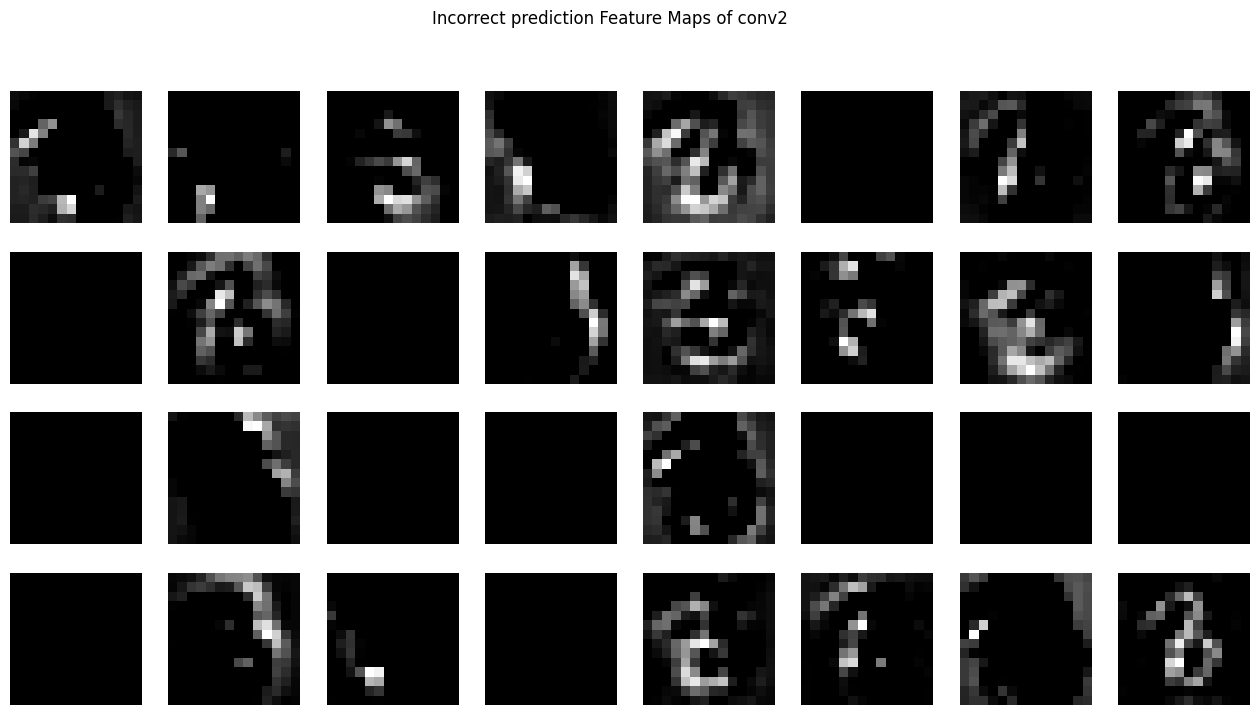

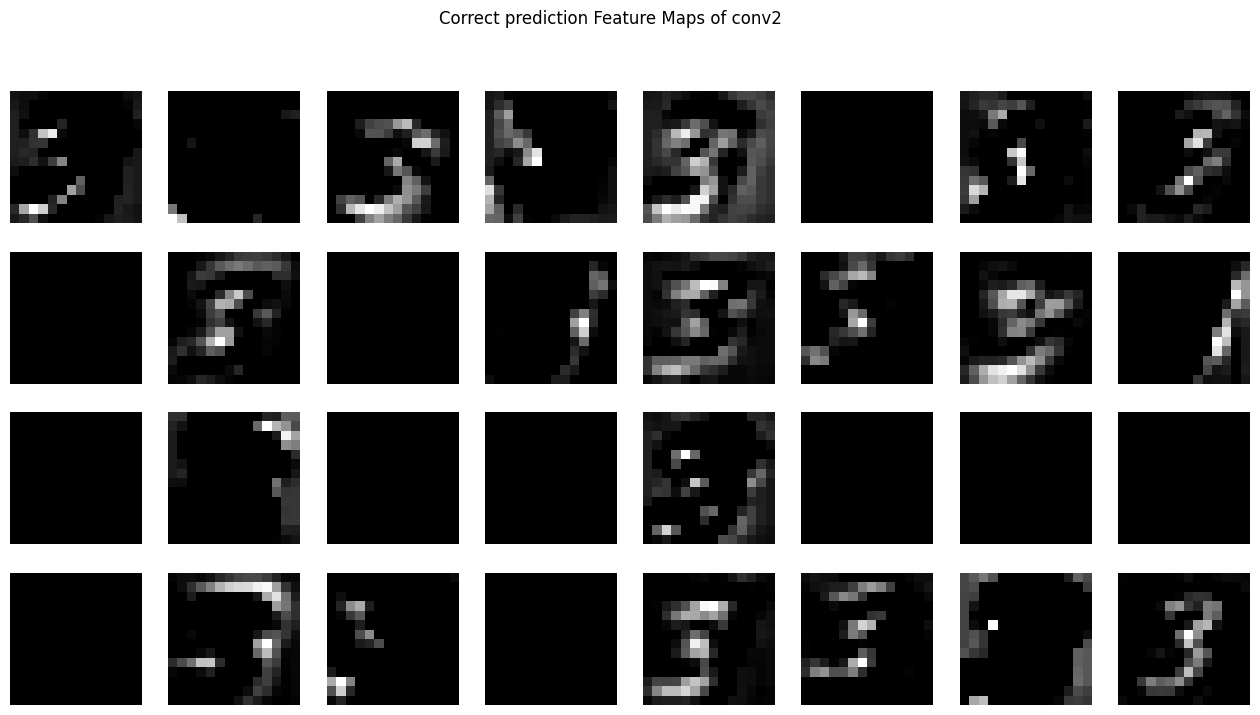

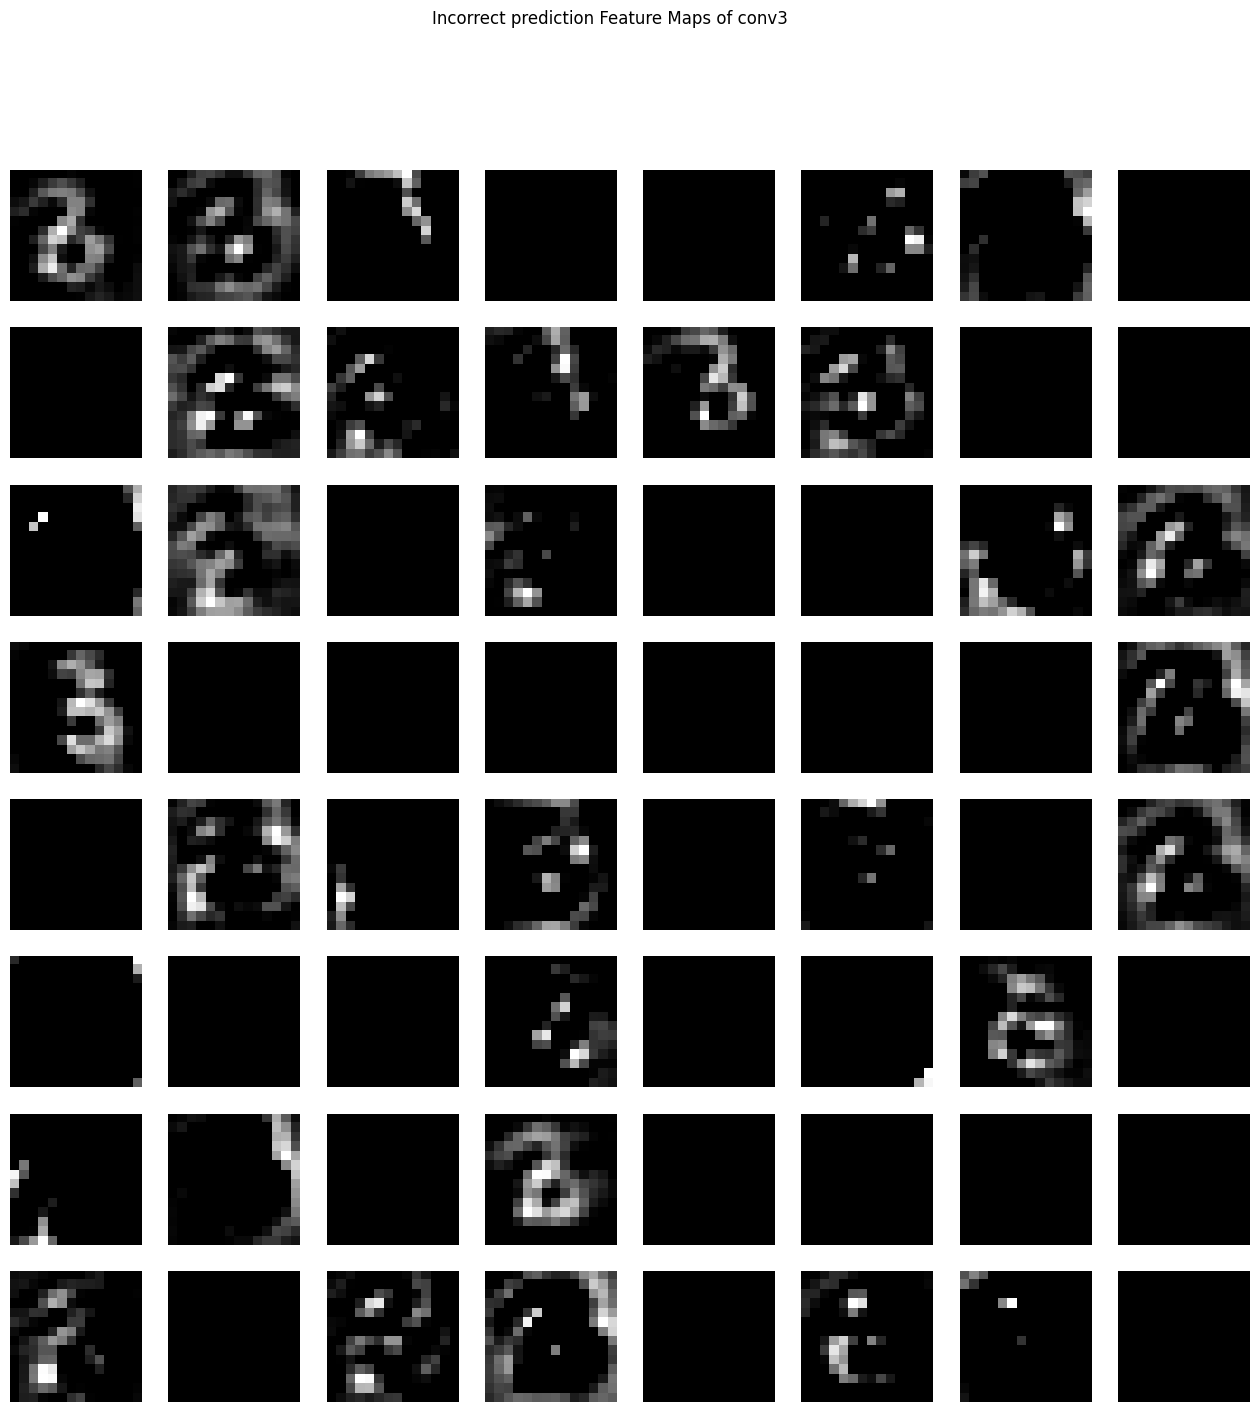

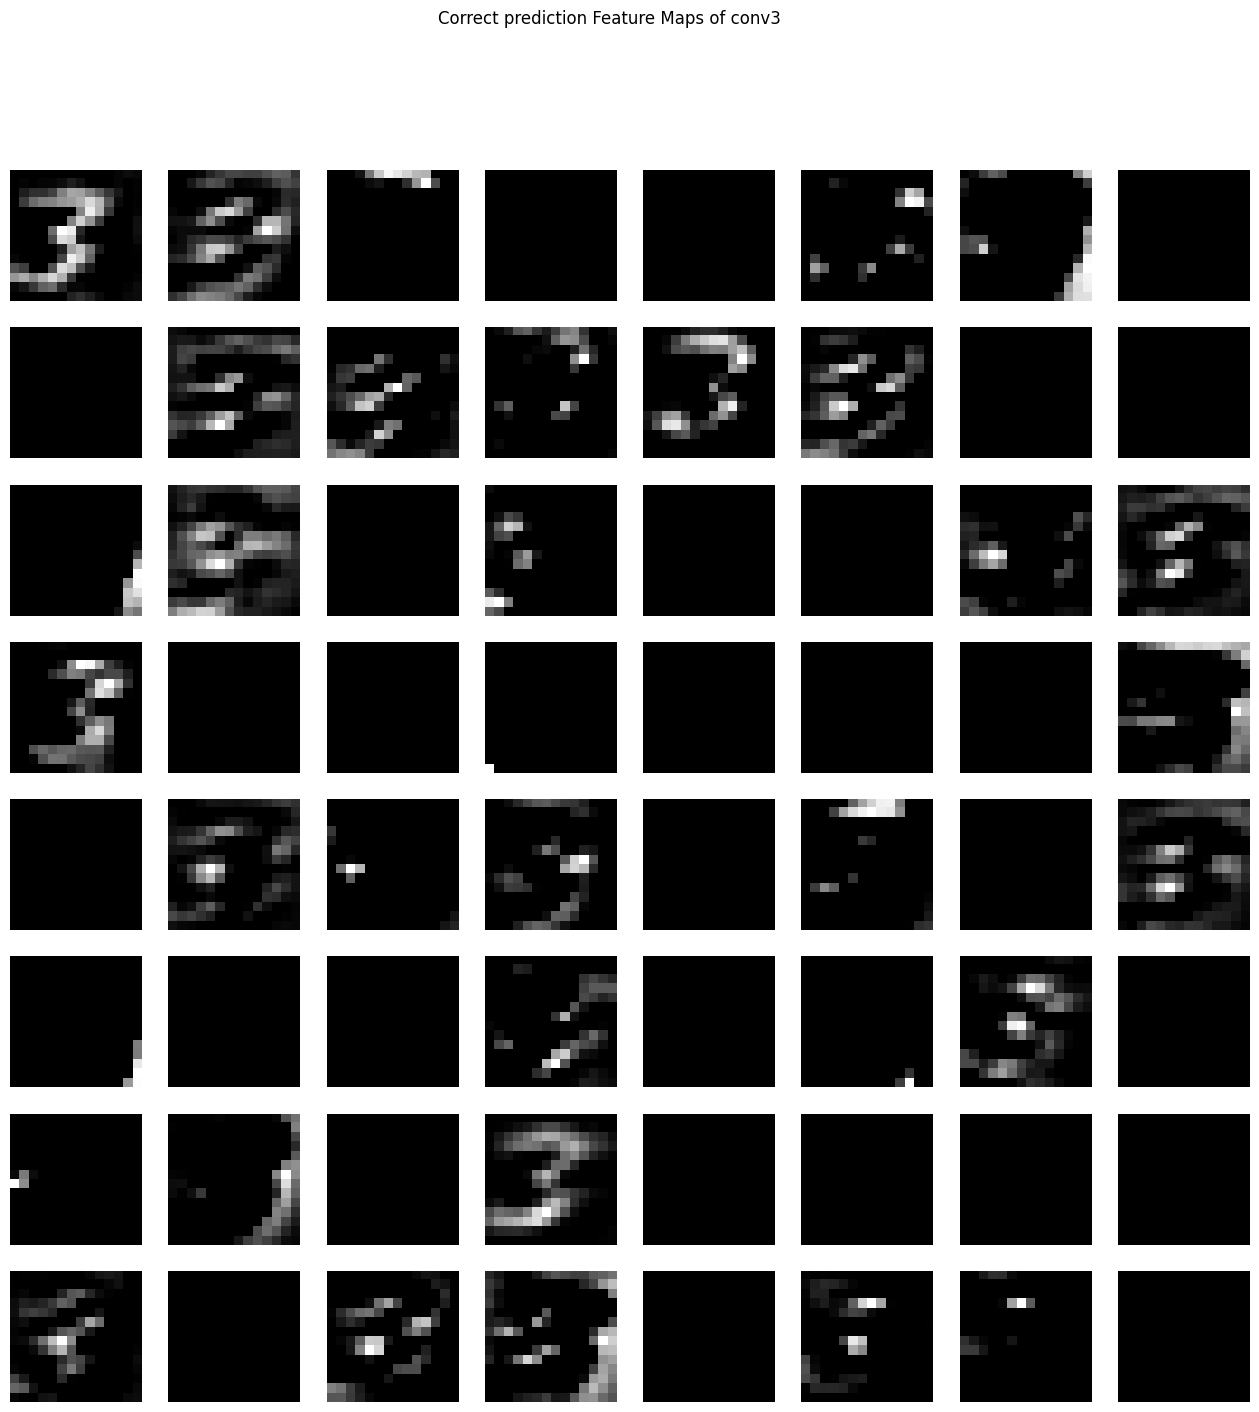

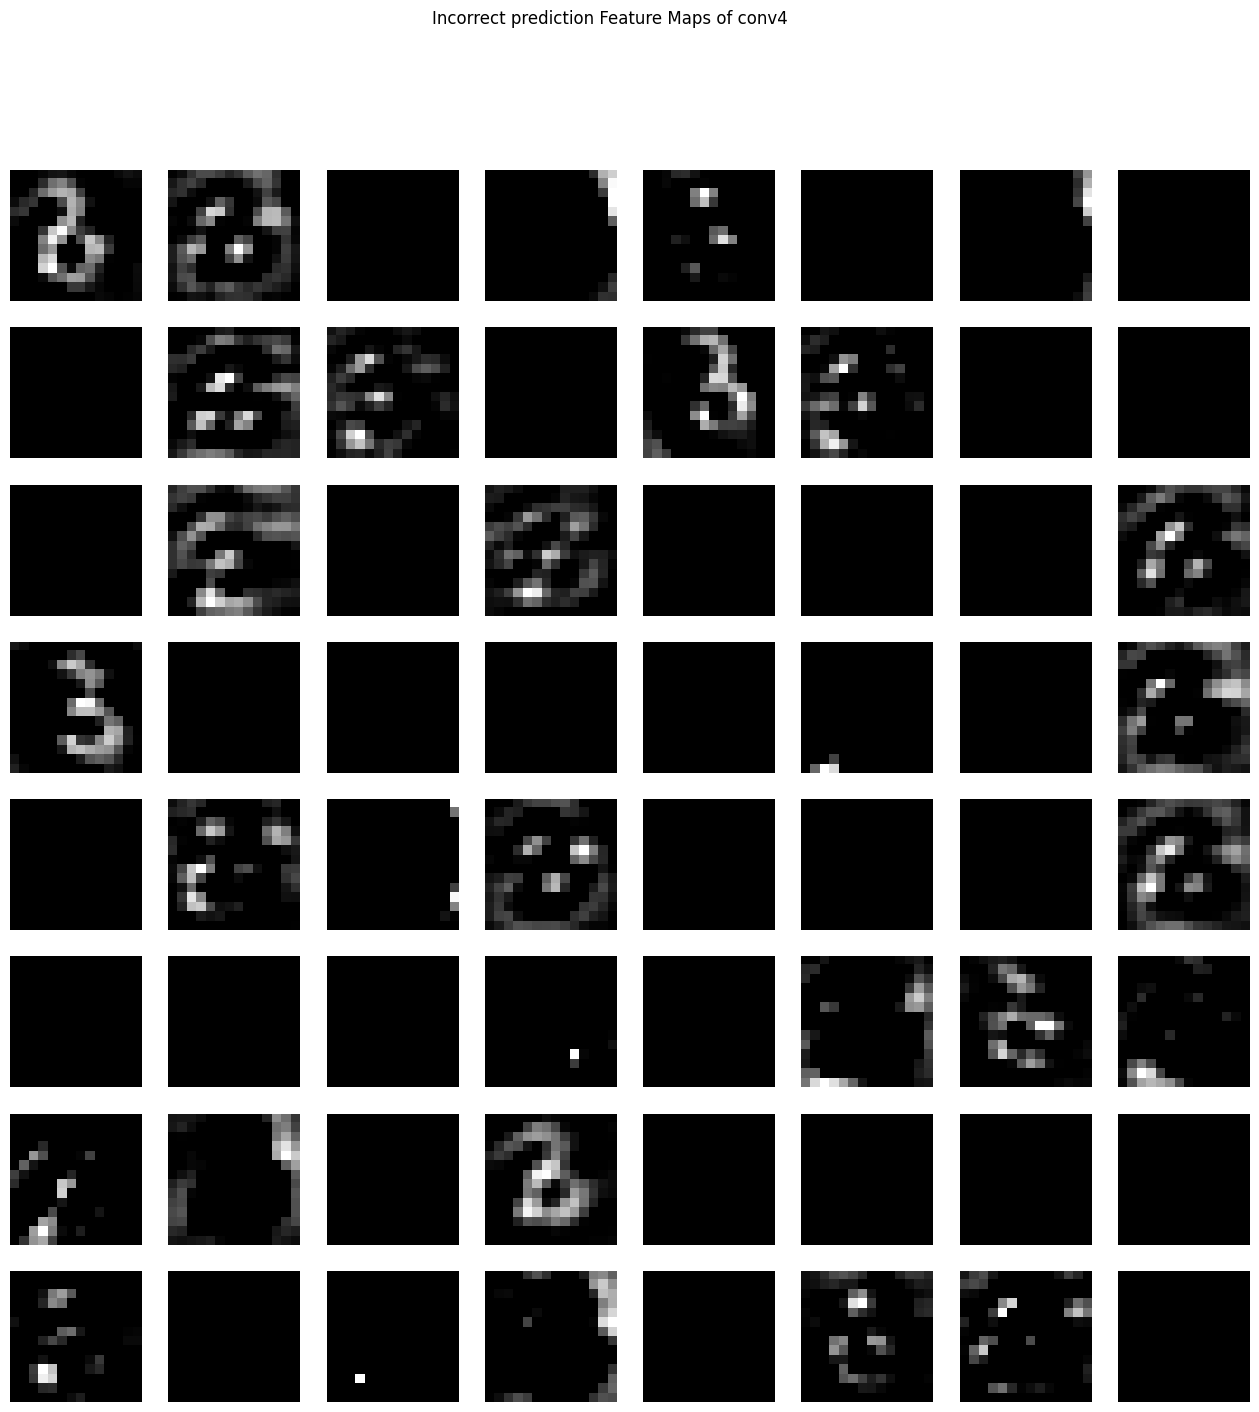

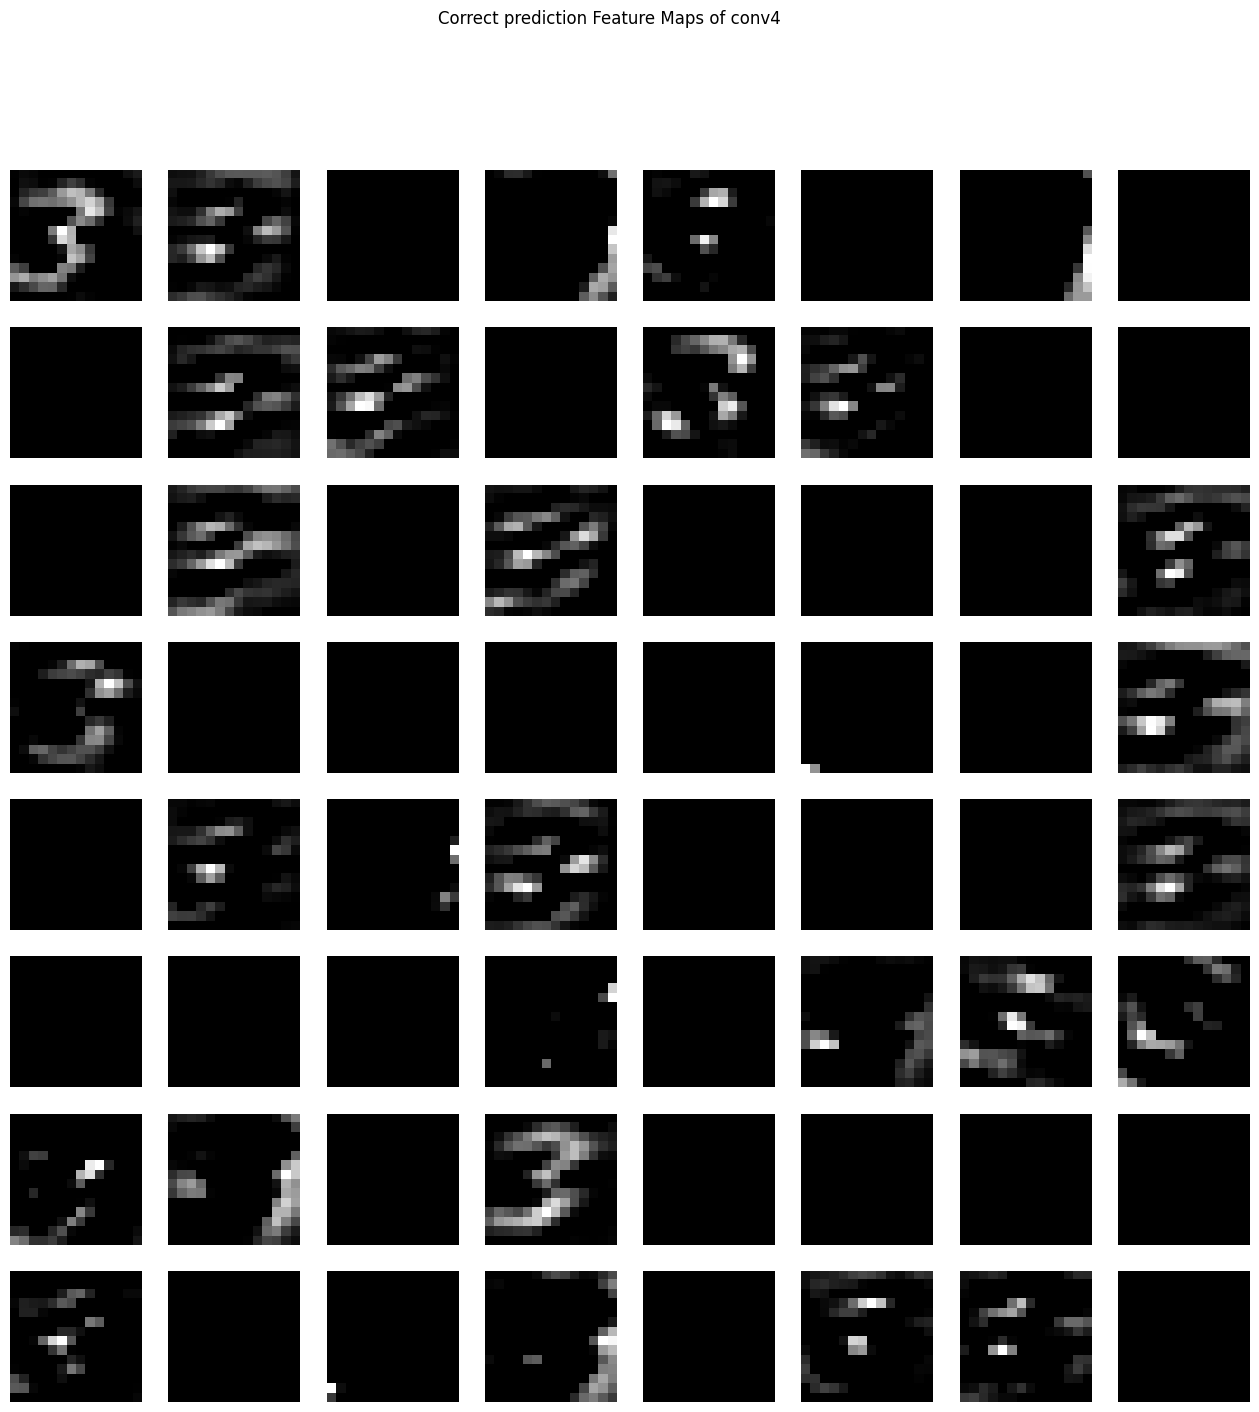

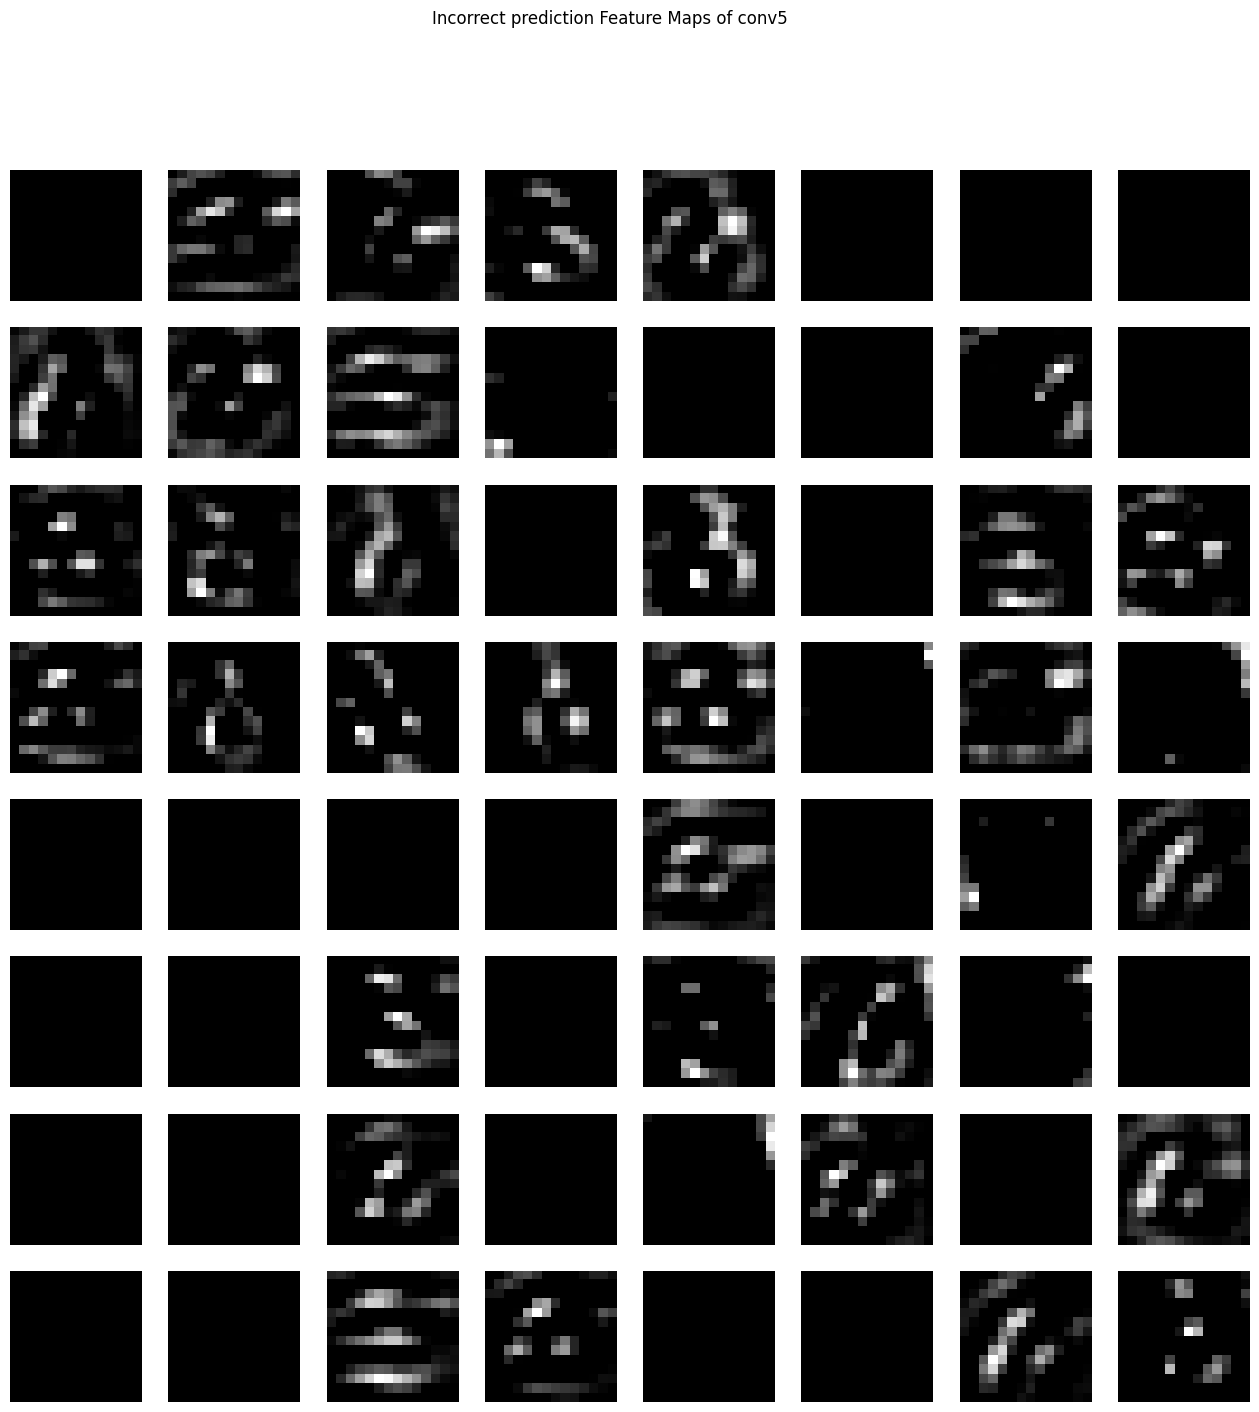

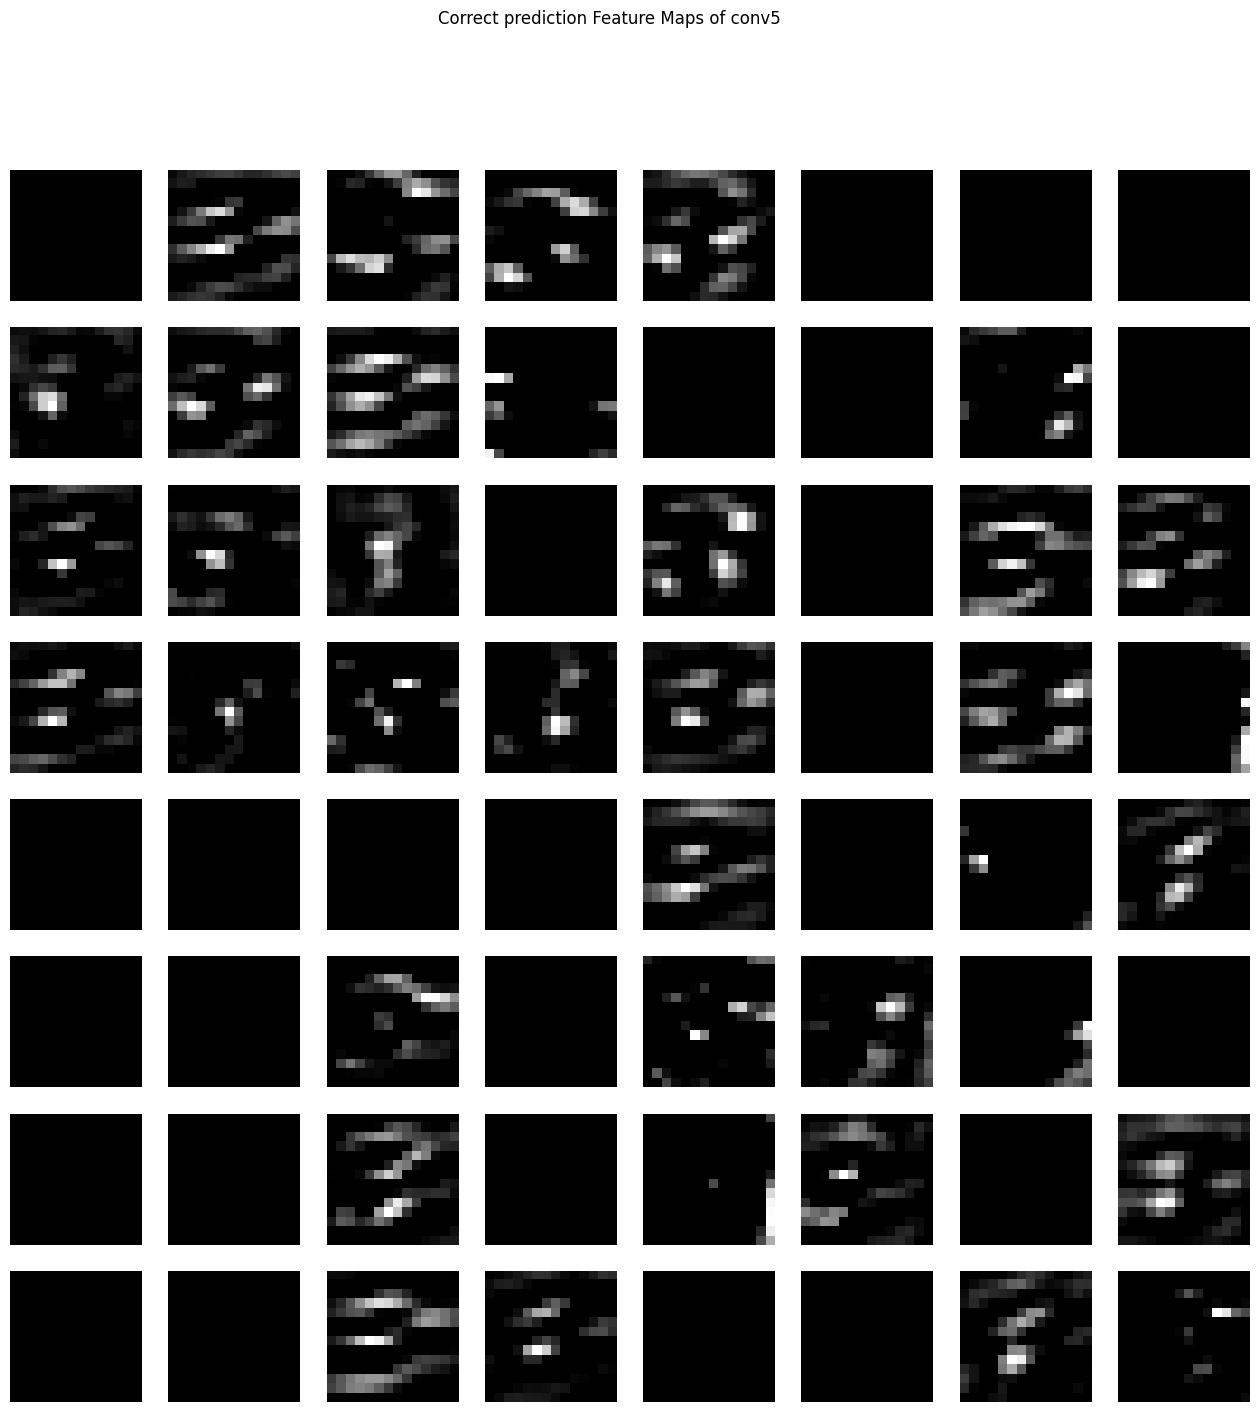

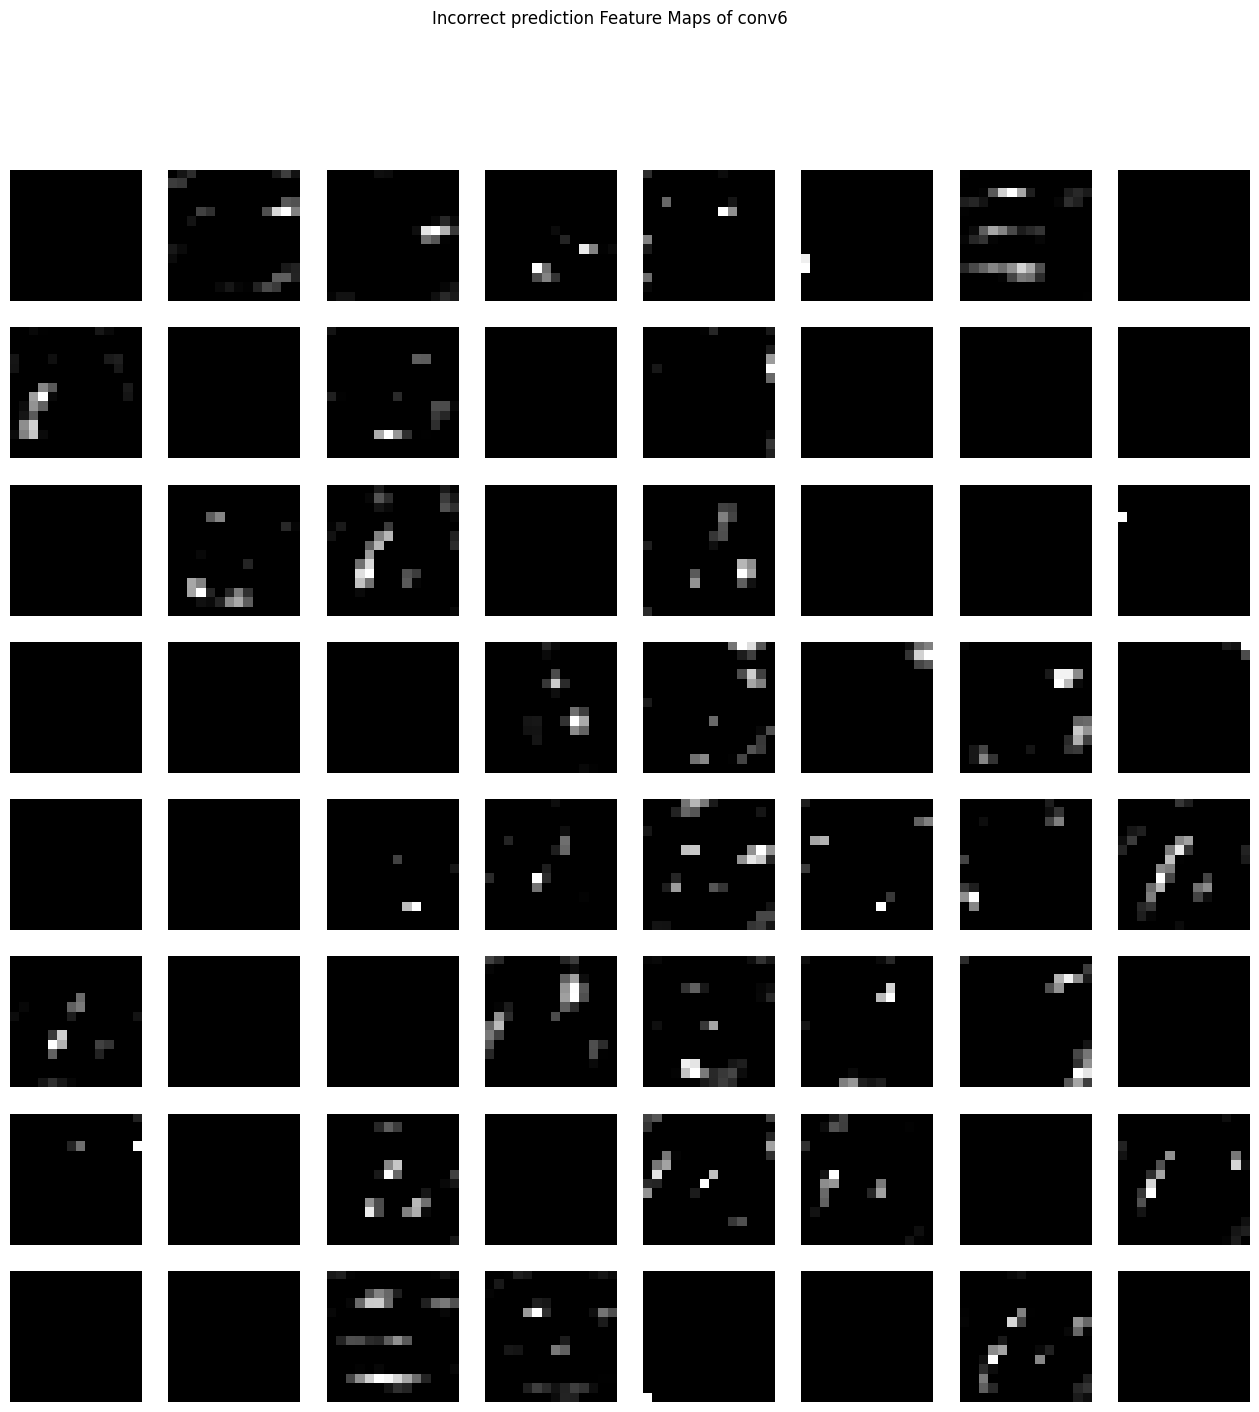

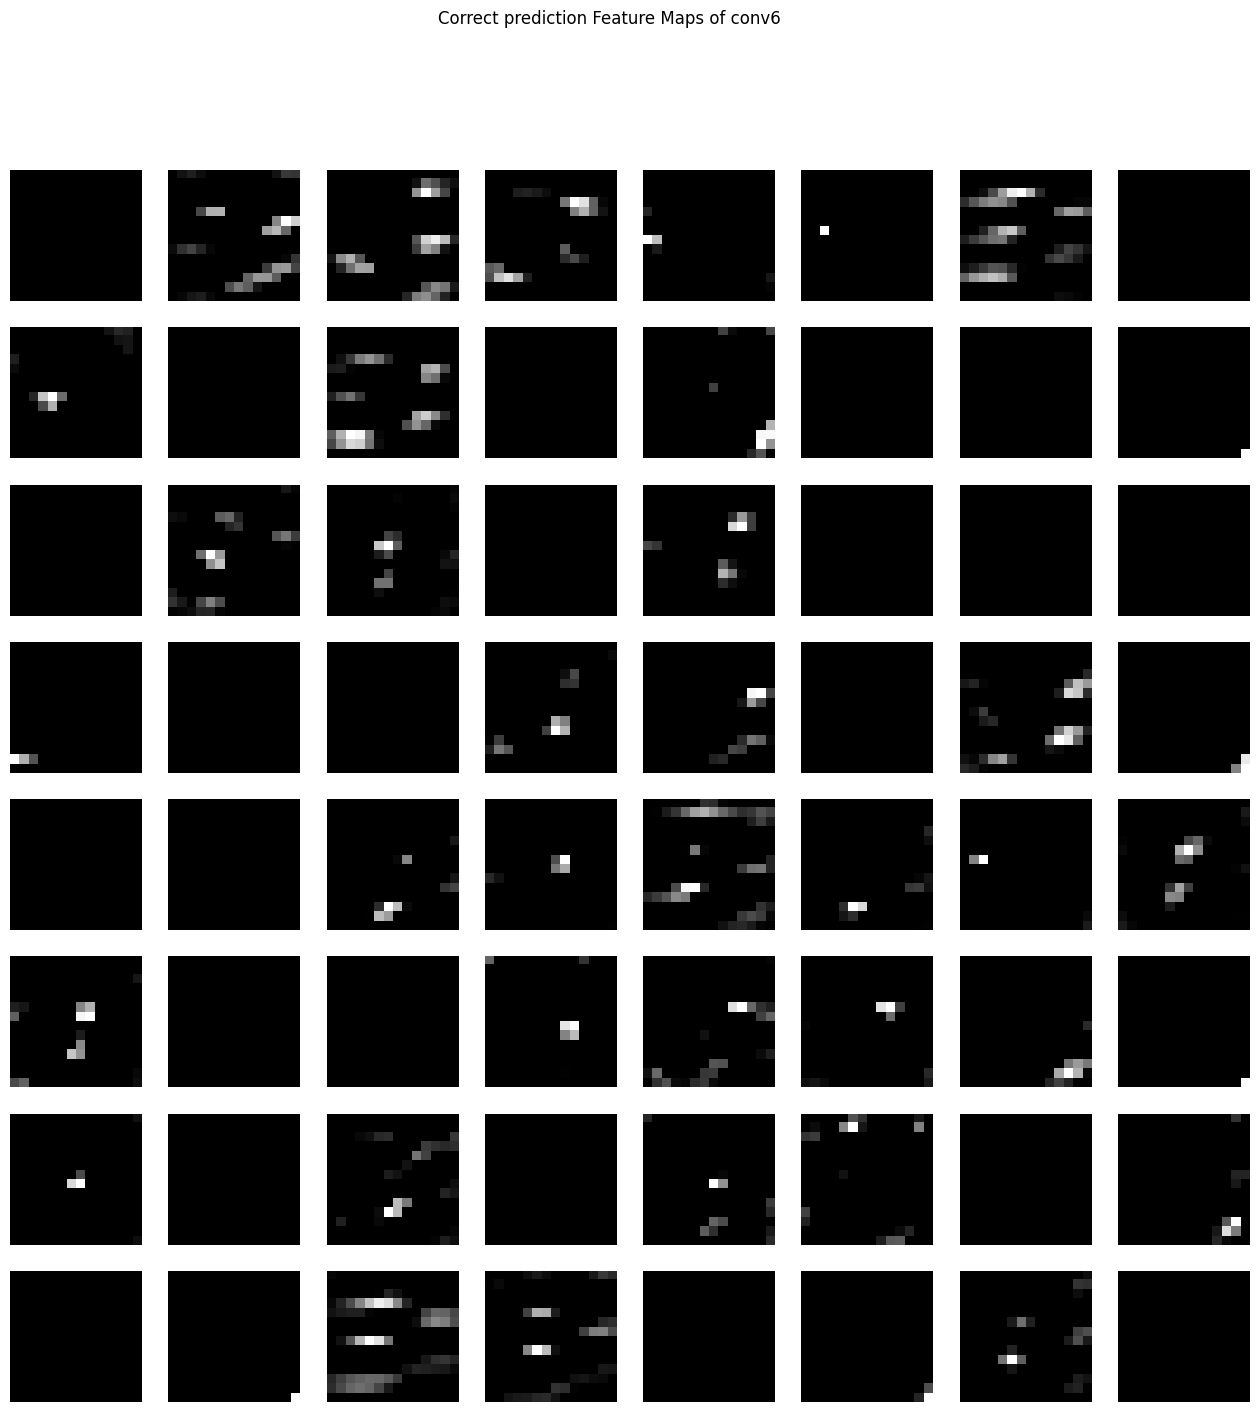

100%|██████████| 312/312 [00:44<00:00,  6.94it/s]


Test Set: Average loss: 0.0263, Accuracy: 98.99%


In [ ]:
result, accuracy = test(model, test_dl)